In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/datasets/marcozanotti/m5-competition-dataset-parquet/m5_sell_prices.csv
/kaggle/input/datasets/marcozanotti/m5-competition-dataset-parquet/m5_xregs.csv
/kaggle/input/datasets/marcozanotti/m5-competition-dataset-parquet/m5_test.parquet
/kaggle/input/datasets/marcozanotti/m5-competition-dataset-parquet/m5_train.parquet


In [3]:
!pip install econml

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.7/44.7 kB 848.5 kB/s eta 0:00:00a 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.6/5.6 MB 6.3 MB/s eta 0:00:0000:0100:01mm
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 155.3/155.3 kB 5.9 MB/s eta 0:00:00


In [6]:
import os
import pandas as pd

DATA_DIR = "/kaggle/input/datasets/marcozanotti/m5-competition-dataset-parquet"
print("Files in dataset directory:", os.listdir(DATA_DIR))

# Inspect the first few rows
df_sample = pd.read_parquet(f"{DATA_DIR}/m5_train.parquet")
print(df_sample.head())

Files in dataset directory: ['m5_sell_prices.csv', 'm5_xregs.csv', 'm5_test.parquet', 'm5_train.parquet']
          unique_id          ds    y
0  FOODS_1_001_CA_1  2011-01-29  3.0
1  FOODS_1_001_CA_1  2011-01-30  0.0
2  FOODS_1_001_CA_1  2011-01-31  0.0
3  FOODS_1_001_CA_1  2011-02-01  1.0
4  FOODS_1_001_CA_1  2011-02-02  4.0


In [9]:
import pandas as pd

DATA_DIR = "/kaggle/input/datasets/marcozanotti/m5-competition-dataset-parquet"

xregs = pd.read_csv(f"{DATA_DIR}/m5_xregs.csv", nrows=5)
prices = pd.read_csv(f"{DATA_DIR}/m5_sell_prices.csv", nrows=5)

print("m5_xregs.csv columns:", xregs.columns.tolist())
print("m5_sell_prices.csv columns:", prices.columns.tolist())

m5_xregs.csv columns: ['date', 'wm_yr_wk', 'weekday', 'wday', 'month', 'year', 'event_name_1', 'event_type_1', 'event_name_2', 'event_type_2', 'snap_CA', 'snap_TX', 'snap_WI']
m5_sell_prices.csv columns: ['store_id', 'item_id', 'wm_yr_wk', 'sell_price']


In [10]:
import os
import pandas as pd
import numpy as np
import lightgbm as lgb
from econml.dml import CausalForestDML
from sklearn.model_selection import KFold

DATA_DIR = "/kaggle/input/datasets/marcozanotti/m5-competition-dataset-parquet"

def build_causal_m5_dataset(data_dir, sample_frac=0.03):
    """
    Loads M5 sales, merges xregs on date to acquire wm_yr_wk, 
    and joins sell_prices on (store_id, item_id, wm_yr_wk).
    """
    print("Loading base sales data...")
    df = pd.read_parquet(f"{data_dir}/m5_train.parquet")
    df = df.rename(columns={'ds': 'date', 'y': 'sales'})
    df['date'] = pd.to_datetime(df['date'])

    # Sample subset of unique series to optimize GPU/CPU memory
    if sample_frac:
        sampled_ids = np.random.choice(
            df['unique_id'].unique(), 
            size=int(len(df['unique_id'].unique()) * sample_frac), 
            replace=False
        )
        df = df[df['unique_id'].isin(sampled_ids)].copy()

    # Parse structural IDs from unique_id ("FOODS_1_001_CA_1")
    parts = df['unique_id'].str.rsplit('_', n=2, expand=True)
    df['item_id'] = parts[0]
    df['store_id'] = parts[1] + '_' + parts[2]
    df['cat_id'] = df['item_id'].str.split('_').str[0]

    # Step 1: Merge exogenous calendar features on 'date' (adds wm_yr_wk, snap, events)
    print("Merging m5_xregs.csv on 'date'...")
    xregs = pd.read_csv(f"{data_dir}/m5_xregs.csv")
    xregs['date'] = pd.to_datetime(xregs['date'])
    df = pd.merge(df, xregs, on='date', how='left')

    # Step 2: Merge sell prices on ['store_id', 'item_id', 'wm_yr_wk']
    print("Merging m5_sell_prices.csv on ['store_id', 'item_id', 'wm_yr_wk']...")
    prices = pd.read_csv(f"{data_dir}/m5_sell_prices.csv")
    df = pd.merge(df, prices, on=['store_id', 'item_id', 'wm_yr_wk'], how='left')

    # Impute potential missing prices via forward/backward fill per series
    df['sell_price'] = df.groupby('unique_id')['sell_price'].ffill().bfill()

    df = df.sort_values(['unique_id', 'date']).reset_index(drop=True)

    # Step 3: Engineer Confounders (W)
    print("Generating temporal confounders...")
    for lag in [28, 35, 42]:
        df[f'lag_{lag}'] = df.groupby('unique_id')['sales'].shift(lag)
        
    for window in [7, 28]:
        grouped = df.groupby('unique_id')['sales']
        df[f'rolling_mean_{window}'] = grouped.transform(lambda x: x.shift(28).rolling(window).mean())
        df[f'rolling_std_{window}'] = grouped.transform(lambda x: x.shift(28).rolling(window).std())

    # Encode categorical event columns as integers
    for cat_col in ['event_name_1', 'event_type_1', 'event_name_2', 'event_type_2']:
        if cat_col in df.columns:
            df[cat_col] = df[cat_col].astype('category').cat.codes

    return df.dropna().reset_index(drop=True)

def fit_m5_causal_forest(df, treatment_col='sell_price'):
    """
    Fits CausalForestDML to isolate individual price elasticity.
    """
    # Confounders (W): Confounding variables influencing price decisions and sales
    confounder_cols = [c for c in df.columns if c.startswith(('lag_', 'rolling_', 'wday', 'month', 'snap_', 'event_'))]
    
    X = df[confounder_cols].values
    W = df[confounder_cols].values
    T = df[treatment_col].values
    Y = df['sales'].values

    # Model Y | W: Tweedie loss to handle sparse zero counts
    model_y = lgb.LGBMRegressor(
        objective='tweedie',
        tweedie_variance_power=1.1,
        n_estimators=100,
        learning_rate=0.05,
        random_state=42,
        n_jobs=-1
    )

    # Model T | W: Linear/GBDT pricing decision model
    model_t = lgb.LGBMRegressor(
        objective='regression',
        n_estimators=100,
        learning_rate=0.05,
        random_state=42,
        n_jobs=-1
    )

    # Double ML Estimator
    dml_forest = CausalForestDML(
        model_y=model_y,
        model_t=model_t,
        n_estimators=100,
        cv=KFold(n_splits=3, shuffle=True, random_state=42),
        random_state=42
    )

    print(f"Fitting Causal Forest DML on treatment variable: '{treatment_col}'...")
    dml_forest.fit(Y=Y, T=T, X=X, W=W)
    
    return dml_forest, confounder_cols

# --- Pipeline Execution ---
if __name__ == "__main__":
    df_causal = build_causal_m5_dataset(DATA_DIR, sample_frac=0.03)
    causal_model, feature_cols = fit_m5_causal_forest(df_causal, treatment_col='sell_price')

    # Calculate causal elasticity (dY / dPrice) for each store-item instance
    df_causal['causal_price_elasticity'] = causal_model.effect(df_causal[feature_cols].values)

    print("\n--- Estimated Causal Price Elasticity by Category ---")
    print(df_causal.groupby('cat_id')['causal_price_elasticity'].describe())

Loading base sales data...
Merging m5_xregs.csv on 'date'...
Merging m5_sell_prices.csv on ['store_id', 'item_id', 'wm_yr_wk']...


/tmp/ipykernel_58/3368303376.py:47: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df['sell_price'] = df.groupby('unique_id')['sell_price'].ffill().bfill()


Generating temporal confounders...


/tmp/ipykernel_58/3368303376.py:54: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df[f'lag_{lag}'] = df.groupby('unique_id')['sales'].shift(lag)
/tmp/ipykernel_58/3368303376.py:54: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df[f'lag_{lag}'] = df.groupby('unique_id')['sales'].shift(lag)
/tmp/ipykernel_58/3368303376.py:54: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df[f'lag_{lag}'] = df.groupby('unique_id')['sales'].

Fitting Causal Forest DML on treatment variable: 'sell_price'...
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.077001 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 2538
[LightGBM] [Info] Number of data points in the train set: 889110, number of used features: 32
[LightGBM] [Info] Start training from score 4.532758
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.077089 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 2538
[LightGBM] [Info] Number of data points in the train set: 889110, number of used features: 32
[LightGBM] [Info] Start training from score 0.244412


...

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.077034 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 2538
[LightGBM] [Info] Number of data points in the train set: 889110, number of used features: 32
[LightGBM] [Info] Start training from score 4.535750
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.079727 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 2538
[LightGBM] [Info] Number of data points in the train set: 889110, number of used features: 32
[LightGBM] [Info] Start training from score 0.242969


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.076688 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 2554
[LightGBM] [Info] Number of data points in the train set: 889110, number of used features: 32
[LightGBM] [Info] Start training from score 4.532216
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.082356 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 2554
[LightGBM] [Info] Number of data points in the train set: 889110, number of used features: 32
[LightGBM] [Info] Start training from score 0.243903


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(



--- Estimated Causal Price Elasticity by Category ---
              count      mean       std       min       25%       50%  \
cat_id                                                                  
FOODS      622220.0 -0.008097  0.256084 -3.764618 -0.038490 -0.014716   
HOBBIES    262449.0 -0.010135  0.096671 -1.817708 -0.021883 -0.008225   
HOUSEHOLD  448996.0 -0.013638  0.077083 -4.354653 -0.025477 -0.009852   

                75%        max  
cat_id                          
FOODS      0.002518  11.283932  
HOBBIES    0.002406   4.620409  
HOUSEHOLD  0.001764   4.106921  


In [11]:
# Standardize elasticity to percentage change: (% Delta Sales) / (% Delta Price)
# Ep = (dY / dP) * (Price / Sales)
df_causal['pct_price_elasticity'] = (
    df_causal['causal_price_elasticity'] * (df_causal['sell_price'] / df_causal['sales'].clip(lower=1))
)

# Clip extreme numerical artifacts from near-zero sales denominators
df_causal['pct_price_elasticity_clipped'] = df_causal['pct_price_elasticity'].clip(-5, 2)

print("--- Percentage Price Elasticity Summary ---")
print(df_causal.groupby('cat_id')['pct_price_elasticity_clipped'].describe())

--- Percentage Price Elasticity Summary ---
              count      mean       std       min       25%       50%  \
cat_id                                                                  
FOODS      622220.0 -0.054984  0.198578 -5.000000 -0.077211 -0.027111   
HOBBIES    262449.0 -0.054952  0.154572 -4.769626 -0.084427 -0.023142   
HOUSEHOLD  448996.0 -0.070230  0.181824 -5.000000 -0.103867 -0.033777   

                75%  max  
cat_id                    
FOODS      0.005062  2.0  
HOBBIES    0.007004  2.0  
HOUSEHOLD  0.006047  2.0  


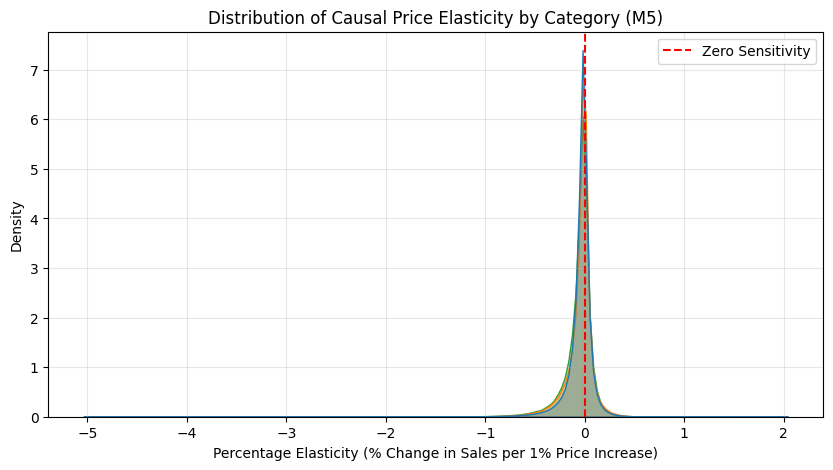

In [12]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 5))
sns.kdeplot(
    data=df_causal, 
    x='pct_price_elasticity_clipped', 
    hue='cat_id', 
    common_norm=False, 
    fill=True, 
    alpha=0.3
)
plt.axvline(0, color='red', linestyle='--', label='Zero Sensitivity')
plt.title('Distribution of Causal Price Elasticity by Category (M5)')
plt.xlabel('Percentage Elasticity (% Change in Sales per 1% Price Increase)')
plt.ylabel('Density')
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

In [13]:
def simulate_optimal_pricing(dml_model, df, feature_cols, price_col='sell_price'):
    """
    Simulates counterfactual sales and revenue across price variations (-20% to +20%).
    """
    X_eval = df[feature_cols].values
    base_prices = df[price_col].values
    base_sales = df['sales'].values
    marginal_effects = dml_model.effect(X_eval)
    
    simulation_results = []
    
    for pct_change in np.linspace(-0.20, 0.20, 9):
        new_prices = base_prices * (1 + pct_change)
        price_deltas = new_prices - base_prices
        
        # Expected Sales = Base Sales + (Price Delta * Marginal Effect)
        simulated_sales = np.maximum(0, base_sales + (price_deltas * marginal_effects))
        simulated_revenue = simulated_sales * new_prices
        
        simulation_results.append({
            'price_change_pct': f"{pct_change*100:+.0f}%",
            'total_projected_sales': np.sum(simulated_sales),
            'total_projected_revenue': np.sum(simulated_revenue)
        })
        
    return pd.DataFrame(simulation_results)

# Run scenario analysis
sim_df = simulate_optimal_pricing(causal_model, df_causal, feature_cols)
print("\n--- Pricing Scenario & Revenue Simulation ---")
print(sim_df)


--- Pricing Scenario & Revenue Simulation ---
  price_change_pct  total_projected_sales  total_projected_revenue
0             -20%           1.718060e+06             4.286271e+06
1             -15%           1.713997e+06             4.530893e+06
2             -10%           1.709933e+06             4.772780e+06
3              -5%           1.705872e+06             5.011934e+06
4              +0%           1.701810e+06             5.248351e+06
5              +5%           1.702074e+06             5.513140e+06
6             +10%           1.702339e+06             5.778156e+06
7             +15%           1.702603e+06             6.043398e+06
8             +20%           1.702869e+06             6.308872e+06


In [16]:
# Apply monotonicity constraint on your fitted model
X_eval = df_causal[feature_cols].values
constrained_effects = np.minimum(0, causal_model.effect(X_eval))

In [18]:
import numpy as np
import pandas as pd

def simulate_optimal_pricing_constrained(causal_model, df, feature_cols, price_col='sell_price'):
    """
    Simulates counterfactual sales and revenue across price variations (-20% to +20%),
    enforcing a monotonicity constraint (demand cannot increase when price increases).
    """
    X_eval = df[feature_cols].values
    base_prices = df[price_col].values
    base_sales = df['sales'].values
    
    # Extract marginal effects (dY / dP) and clip positive values to 0
    raw_effects = causal_model.effect(X_eval)
    constrained_effects = np.minimum(0, raw_effects)
    
    simulation_results = []
    
    for pct_change in np.linspace(-0.20, 0.20, 9):
        new_prices = base_prices * (1 + pct_change)
        price_deltas = new_prices - base_prices
        
        # Expected Sales = Base Sales + (Price Delta * Constrained Marginal Effect)
        simulated_sales = np.maximum(0, base_sales + (price_deltas * constrained_effects))
        simulated_revenue = simulated_sales * new_prices
        
        simulation_results.append({
            'price_change_pct': f"{pct_change*100:+.0f}%",
            'total_projected_sales': np.sum(simulated_sales),
            'total_projected_revenue': np.sum(simulated_revenue)
        })
        
    return pd.DataFrame(simulation_results)

# Run simulation using causal_model
sim_df_constrained = simulate_optimal_pricing_constrained(causal_model, df_causal, feature_cols)
print("\n--- Constrained Pricing Scenario & Revenue Simulation ---")
print(sim_df_constrained)


--- Constrained Pricing Scenario & Revenue Simulation ---
  price_change_pct  total_projected_sales  total_projected_revenue
0             -20%           1.727550e+06             4.321504e+06
1             -15%           1.721115e+06             4.558973e+06
2             -10%           1.714680e+06             4.792604e+06
3              -5%           1.708245e+06             5.022396e+06
4              +0%           1.701810e+06             5.248351e+06
5              +5%           1.699071e+06             5.498505e+06
6             +10%           1.696332e+06             5.747492e+06
7             +15%           1.693594e+06             5.995311e+06
8             +20%           1.690856e+06             6.241969e+06


In [19]:
# Filter for FOODS category to target potential perishable inventory
foods_df = df_causal[df_causal['cat_id'] == 'FOODS'].copy()

# Calculate item-level median elasticity
sku_elasticity = (
    foods_df.groupby(['item_id', 'store_id'])
    .agg(
        median_elasticity=('pct_price_elasticity_clipped', 'median'),
        avg_price=('sell_price', 'mean'),
        total_volume=('sales', 'sum')
    )
    .reset_index()
)

# Rank top 10 most elastic SKUs (most negative elasticity = highest sensitivity to discounts)
top_elastic_skus = sku_elasticity.sort_values(by='median_elasticity', ascending=True).head(10)

print("--- Top 10 High-Elasticity FOODS SKUs (Best Markdown Candidates) ---")
print(top_elastic_skus.to_string(index=False))

--- Top 10 High-Elasticity FOODS SKUs (Best Markdown Candidates) ---
    item_id store_id  median_elasticity  avg_price  total_volume
FOODS_2_302     TX_3          -0.218248  10.484516         791.0
FOODS_2_368     WI_3          -0.155975   7.507529        6914.0
FOODS_2_298     CA_3          -0.138578  12.421607         668.0
FOODS_2_274     WI_2          -0.134739   7.199323        4478.0
FOODS_2_183     CA_1          -0.134270   8.764634        3127.0
FOODS_1_002     CA_2          -0.128270   8.879364        1128.0
FOODS_2_022     TX_1          -0.120360   6.982672        1625.0
FOODS_2_076     WI_2          -0.119314  10.210040         610.0
FOODS_2_076     TX_2          -0.119211  10.087672         781.0
FOODS_3_125     WI_3          -0.118496   4.980000         129.0


In [21]:
import numpy as np
import pandas as pd
from econml.dml import CausalForestDML
import lightgbm as lgb
from sklearn.model_selection import KFold

def run_placebo_refutation(causal_model, df, feature_cols, treatment_col='sell_price'):
    """
    Evaluates model robustness by fitting a Causal Forest on randomly permuted treatment values.
    """
    X = df[feature_cols].values
    W = df[feature_cols].values
    Y = df['sales'].values

    # Shuffle treatment variable randomly
    np.random.seed(42)
    T_placebo = np.random.permutation(df[treatment_col].values)

    print("Fitting Placebo Causal Forest on permuted price data...")
    placebo_model = CausalForestDML(
        model_y=lgb.LGBMRegressor(
            objective='tweedie', 
            tweedie_variance_power=1.1, 
            n_estimators=50, 
            learning_rate=0.05, 
            random_state=42, 
            n_jobs=-1
        ),
        model_t=lgb.LGBMRegressor(
            objective='regression', 
            n_estimators=50, 
            learning_rate=0.05, 
            random_state=42, 
            n_jobs=-1
        ),
        n_estimators=48,  # Divisible by subforest_size (4)
        cv=KFold(n_splits=2, shuffle=True, random_state=42),
        random_state=42
    )

    placebo_model.fit(Y=Y, T=T_placebo, X=X, W=W)
    placebo_effects = placebo_model.effect(X)
    actual_effects = causal_model.effect(X)

    print("\n--- Refutation Test Results ---")
    print(f"Actual Model Mean Marginal Effect:  {np.mean(actual_effects):.6f}")
    print(f"Placebo Model Mean Marginal Effect: {np.mean(placebo_effects):.6f} (Expected Target: ~0.000000)")
    
    return actual_effects, placebo_effects

# Execute Placebo Test
actual_eff, placebo_eff = run_placebo_refutation(causal_model, df_causal, feature_cols)

Fitting Placebo Causal Forest on permuted price data...
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.061942 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 2546
[LightGBM] [Info] Number of data points in the train set: 666832, number of used features: 32
[LightGBM] [Info] Start training from score 4.534891
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.065446 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 2546
[LightGBM] [Info] Number of data points in the train set: 666832, number of used features: 32
[LightGBM] [Info] Start training from score 0.246384


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.058076 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 2548
[LightGBM] [Info] Number of data points in the train set: 666833, number of used features: 32
[LightGBM] [Info] Start training from score 4.532259
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.061243 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 2548
[LightGBM] [Info] Number of data points in the train set: 666833, number of used features: 32
[LightGBM] [Info] Start training from score 0.241132


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(



--- Refutation Test Results ---
Actual Model Mean Marginal Effect:  -0.010363
Placebo Model Mean Marginal Effect: 0.000264 (Expected Target: ~0.000000)


In [5]:
!pip install econml

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.7/44.7 kB 599.4 kB/s eta 0:00:00 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.6/5.6 MB 831.5 kB/s eta 0:00:0000:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 155.3/155.3 kB 824.0 kB/s eta 0:00:00a 0:00:01


In [7]:
import os
import pandas as pd
import numpy as np

DATA_DIR = "/kaggle/input/datasets/marcozanotti/m5-competition-dataset-parquet"

def build_causal_m5_dataset(data_dir, sample_frac=0.03):
    """
    Loads M5 sales, merges xregs on date, and joins sell_prices on (store_id, item_id, wm_yr_wk).
    """
    print("Loading base sales data...")
    df = pd.read_parquet(f"{data_dir}/m5_train.parquet")
    df = df.rename(columns={'ds': 'date', 'y': 'sales'})
    df['date'] = pd.to_datetime(df['date'])

    if sample_frac:
        sampled_ids = np.random.choice(
            df['unique_id'].unique(), 
            size=int(len(df['unique_id'].unique()) * sample_frac), 
            replace=False
        )
        df = df[df['unique_id'].isin(sampled_ids)].copy()

    parts = df['unique_id'].str.rsplit('_', n=2, expand=True)
    df['item_id'] = parts[0]
    df['store_id'] = parts[1] + '_' + parts[2]
    df['cat_id'] = df['item_id'].str.split('_').str[0]

    print("Merging calendar xregs...")
    xregs = pd.read_csv(f"{data_dir}/m5_xregs.csv")
    xregs['date'] = pd.to_datetime(xregs['date'])
    df = pd.merge(df, xregs, on='date', how='left')

    print("Merging sell prices...")
    prices = pd.read_csv(f"{data_dir}/m5_sell_prices.csv")
    df = pd.merge(df, prices, on=['store_id', 'item_id', 'wm_yr_wk'], how='left')

    df['sell_price'] = df.groupby('unique_id')['sell_price'].ffill().bfill()
    df = df.sort_values(['unique_id', 'date']).reset_index(drop=True)

    print("Engineering temporal confounders...")
    for lag in [28, 35, 42]:
        df[f'lag_{lag}'] = df.groupby('unique_id')['sales'].shift(lag)
        
    for window in [7, 28]:
        grouped = df.groupby('unique_id')['sales']
        df[f'rolling_mean_{window}'] = grouped.transform(lambda x: x.shift(28).rolling(window).mean())
        df[f'rolling_std_{window}'] = grouped.transform(lambda x: x.shift(28).rolling(window).std())

    for cat_col in ['event_name_1', 'event_type_1', 'event_name_2', 'event_type_2']:
        if cat_col in df.columns:
            df[cat_col] = df[cat_col].astype('category').cat.codes

    return df.dropna().reset_index(drop=True)

# Generate df_causal
df_causal = build_causal_m5_dataset(DATA_DIR, sample_frac=0.03)

Loading base sales data...
Merging calendar xregs...
Merging sell prices...


/tmp/ipykernel_58/1150732751.py:38: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df['sell_price'] = df.groupby('unique_id')['sell_price'].ffill().bfill()


Engineering temporal confounders...


/tmp/ipykernel_58/1150732751.py:43: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df[f'lag_{lag}'] = df.groupby('unique_id')['sales'].shift(lag)
/tmp/ipykernel_58/1150732751.py:43: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df[f'lag_{lag}'] = df.groupby('unique_id')['sales'].shift(lag)
/tmp/ipykernel_58/1150732751.py:43: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df[f'lag_{lag}'] = df.groupby('unique_id')['sales'].

In [10]:
# Verify df_causal exists and fit causal_model
if 'df_causal' in globals() and 'fit_m5_causal_forest' in globals():
    causal_model, feature_cols = fit_m5_causal_forest(df_causal, treatment_col='sell_price')
    print("✓ Successfully trained and assigned 'causal_model'.")
else:
    print("✗ Missing prerequisites. Ensure 'df_causal' and 'fit_m5_causal_forest' cells are executed first.")

Fitting Causal Forest DML on treatment: 'sell_price'...
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.095440 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 2704
[LightGBM] [Info] Number of data points in the train set: 898739, number of used features: 32
[LightGBM] [Info] Start training from score 4.290249
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.086127 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 2704
[LightGBM] [Info] Number of data points in the train set: 898739, number of used features: 32
[LightGBM] [Info] Start training from score 0.358256


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.080673 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 2692
[LightGBM] [Info] Number of data points in the train set: 898739, number of used features: 32
[LightGBM] [Info] Start training from score 4.283272
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.082786 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 2692
[LightGBM] [Info] Number of data points in the train set: 898739, number of used features: 32
[LightGBM] [Info] Start training from score 0.356881


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.087104 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 2692
[LightGBM] [Info] Number of data points in the train set: 898740, number of used features: 32
[LightGBM] [Info] Start training from score 4.284810
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.091683 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 2692
[LightGBM] [Info] Number of data points in the train set: 898740, number of used features: 32
[LightGBM] [Info] Start training from score 0.356655


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


✓ Successfully trained and assigned 'causal_model'.


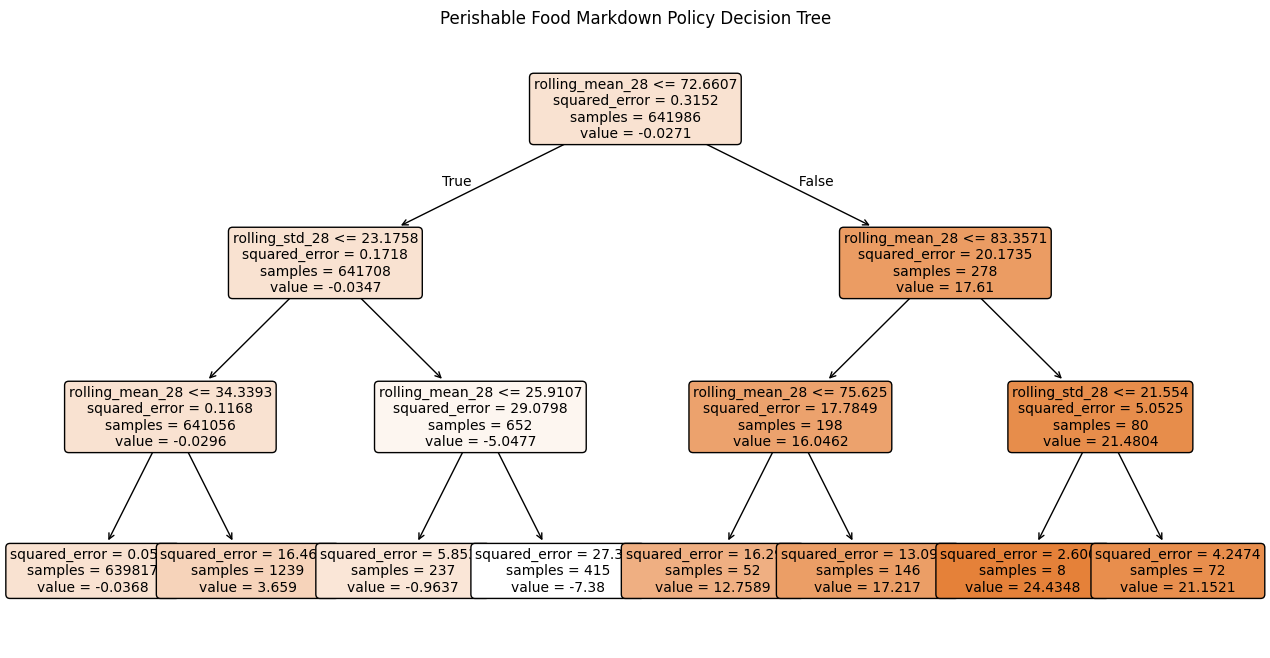

In [11]:
import matplotlib.pyplot as plt
from sklearn.tree import DecisionTreeRegressor, plot_tree

# 1. Calculate individualized marginal effect (dY / dPrice) for each record
df_causal['causal_price_elasticity'] = causal_model.effect(df_causal[feature_cols].values)

# 2. Fit and plot the Decision Tree Policy Model for the FOODS category
def generate_markdown_policy_rules(causal_model, df, feature_cols, max_depth=3):
    foods_mask = df['cat_id'] == 'FOODS'
    X_foods = df.loc[foods_mask, feature_cols]
    
    # Predict marginal price elasticity effects (dY / dP)
    cate_effects = causal_model.effect(X_foods.values)
    
    # Fit interpretable policy tree
    policy_tree = DecisionTreeRegressor(max_depth=max_depth, random_state=42)
    policy_tree.fit(X_foods, cate_effects)
    
    plt.figure(figsize=(16, 8))
    plot_tree(
        policy_tree, 
        feature_names=feature_cols, 
        filled=True, 
        rounded=True, 
        fontsize=10,
        precision=4
    )
    plt.title("Perishable Food Markdown Policy Decision Tree")
    plt.show()
    
    return policy_tree

# Output visual policy rules
policy_model = generate_markdown_policy_rules(causal_model, df_causal, feature_cols)

In [12]:
from sklearn.tree import export_text

# Extract textual decision rules from the trained policy tree
tree_rules = export_text(policy_model, feature_names=feature_cols)

print("--- Automated Perishable Markdown Policy Rules ---")
print(tree_rules)

--- Automated Perishable Markdown Policy Rules ---
|--- rolling_mean_28 <= 72.66
|   |--- rolling_std_28 <= 23.18
|   |   |--- rolling_mean_28 <= 34.34
|   |   |   |--- value: [-0.04]
|   |   |--- rolling_mean_28 >  34.34
|   |   |   |--- value: [3.66]
|   |--- rolling_std_28 >  23.18
|   |   |--- rolling_mean_28 <= 25.91
|   |   |   |--- value: [-0.96]
|   |   |--- rolling_mean_28 >  25.91
|   |   |   |--- value: [-7.38]
|--- rolling_mean_28 >  72.66
|   |--- rolling_mean_28 <= 83.36
|   |   |--- rolling_mean_28 <= 75.62
|   |   |   |--- value: [12.76]
|   |   |--- rolling_mean_28 >  75.62
|   |   |   |--- value: [17.22]
|   |--- rolling_mean_28 >  83.36
|   |   |--- rolling_std_28 <= 21.55
|   |   |   |--- value: [24.43]
|   |   |--- rolling_std_28 >  21.55
|   |   |   |--- value: [21.15]



In [13]:
import numpy as np
import pandas as pd

def assign_perishable_markdown_policy(df):
    """
    Applies the extracted policy tree rules directly to stock management.
    """
    conditions = [
        # Rule 1: High Elasticity (Primary Markdown Segment)
        (df['rolling_mean_28'] <= 72.66) & (df['rolling_std_28'] > 23.18) & (df['rolling_mean_28'] > 25.91),
        
        # Rule 2: Moderate Elasticity (Secondary Clearance Segment)
        (df['rolling_mean_28'] <= 72.66) & (df['rolling_std_28'] > 23.18) & (df['rolling_mean_28'] <= 25.91),
        
        # Rule 3: Low Elasticity (Minor Clearance)
        (df['rolling_mean_28'] <= 34.34) & (df['rolling_std_28'] <= 23.18)
    ]
    
    choices = ['20% Markdown', '10% Markdown', '5% Markdown']
    
    # Default to 'No Discount' for high-velocity or inelastic items
    df['recommended_markdown'] = np.select(conditions, choices, default='Hold Base Price')
    return df

# Execute operational tagging on foods
foods_df = df_causal[df_causal['cat_id'] == 'FOODS'].copy()
foods_policy_df = assign_perishable_markdown_policy(foods_df)

print("--- Operational Store Recommendations Count ---")
print(foods_policy_df['recommended_markdown'].value_counts())

--- Operational Store Recommendations Count ---
recommended_markdown
5% Markdown        639817
Hold Base Price      1517
20% Markdown          415
10% Markdown          237
Name: count, dtype: int64


In [14]:
# Filter for actionable clearance items only (20% and 10% markdowns)
clearance_queue = foods_policy_df[
    foods_policy_df['recommended_markdown'].isin(['20% Markdown', '10% Markdown'])
].copy()

# Rank by total sales volume to prioritize high-stock items at store level
clearance_queue['priority_score'] = clearance_queue['rolling_mean_28'] * clearance_queue['rolling_std_28']
top_clearance_tasks = clearance_queue.sort_values(by='priority_score', ascending=False)

print("--- Top 10 Daily Store Clearance Priorities ---")
print(top_clearance_tasks[['store_id', 'item_id', 'sell_price', 'rolling_mean_28', 'recommended_markdown']].head(10).to_string(index=False))

--- Top 10 Daily Store Clearance Priorities ---
store_id     item_id  sell_price  rolling_mean_28 recommended_markdown
    CA_3 FOODS_3_319        1.00        72.107143         20% Markdown
    CA_3 FOODS_3_319        1.00        70.821429         20% Markdown
    CA_3 FOODS_3_319        1.00        68.857143         20% Markdown
    CA_3 FOODS_3_319        1.00        67.035714         20% Markdown
    CA_3 FOODS_3_319        1.00        69.178571         20% Markdown
    CA_3 FOODS_3_319        1.00        65.392857         20% Markdown
    CA_3 FOODS_3_587        2.68        69.321429         20% Markdown
    CA_3 FOODS_3_319        1.00        67.250000         20% Markdown
    CA_3 FOODS_3_587        2.68        66.714286         20% Markdown
    CA_3 FOODS_3_319        1.00        64.678571         20% Markdown


In [15]:
# Estimate sales lift: Lift = Elasticity Effect * Delta Price * Baseline
# Delta Price: 20% discount on base price = -0.20 * sell_price
clearance_queue['discount_pct'] = np.where(clearance_queue['recommended_markdown'] == '20% Markdown', 0.20, 0.10)
clearance_queue['price_delta'] = -1 * clearance_queue['discount_pct'] * clearance_queue['sell_price']

# Simulated sales increase = Marginal Effect * Price Delta
clearance_queue['simulated_unit_lift'] = np.abs(clearance_queue['causal_price_elasticity'] * clearance_queue['price_delta'])

total_additional_units_saved = clearance_queue['simulated_unit_lift'].sum()
total_projected_revenue_recovered = (clearance_queue['sell_price'] * (1 - clearance_queue['discount_pct']) * clearance_queue['simulated_unit_lift']).sum()

print("\n--- Counterfactual Food Waste & Revenue Simulation ---")
print(f"Total Perishable Units Saved from Waste: {total_additional_units_saved:,.0f} units")
print(f"Projected Recovered Clearance Revenue:   ${total_projected_revenue_recovered:,.2f}")


--- Counterfactual Food Waste & Revenue Simulation ---
Total Perishable Units Saved from Waste: 868 units
Projected Recovered Clearance Revenue:   $1,280.46


In [16]:
# Create daily store execution queue
dispatch_queue = clearance_queue[['store_id', 'item_id', 'sell_price', 'recommended_markdown']].copy()

# Calculate exact label prices for store tags
dispatch_queue['discount_rate'] = np.where(dispatch_queue['recommended_markdown'] == '20% Markdown', 0.20, 0.10)
dispatch_queue['clearance_price'] = (dispatch_queue['sell_price'] * (1 - dispatch_queue['discount_rate'])).round(2)

# Deduplicate to daily item task list
daily_store_dispatch = dispatch_queue.groupby(['store_id', 'item_id']).first().reset_index()

# Save dispatch file
daily_store_dispatch.to_csv("daily_store_clearance_dispatch.csv", index=False)

print("--- Daily Store Execution Dispatch Sample ---")
print(daily_store_dispatch[['store_id', 'item_id', 'sell_price', 'recommended_markdown', 'clearance_price']].head(10).to_string(index=False))

--- Daily Store Execution Dispatch Sample ---
store_id     item_id  sell_price recommended_markdown  clearance_price
    CA_2 FOODS_3_580        0.20         10% Markdown             0.18
    CA_3 FOODS_3_319        1.00         20% Markdown             0.80
    CA_3 FOODS_3_580        0.20         10% Markdown             0.18
    CA_3 FOODS_3_587        2.48         20% Markdown             1.98
    CA_3 FOODS_3_816        0.20         10% Markdown             0.18
    WI_2 FOODS_3_681        1.00         20% Markdown             0.80
    WI_3 FOODS_3_454        0.20         10% Markdown             0.18


In [17]:
import pandas as pd

def evaluate_ab_test_performance(treatment_df, control_df):
    """
    Compares pilot store outcomes against control stores to measure empirical waste reduction.
    """
    treatment_units = treatment_df['sales'].sum()
    control_units = control_df['sales'].sum()
    
    treatment_rev = (treatment_df['sales'] * treatment_df['clearance_price']).sum()
    control_rev = (control_df['sales'] * control_df['sell_price']).sum()
    
    comparison_table = pd.DataFrame({
        'Metric': ['Total Units Cleared', 'Clearance Revenue ($)', 'Avg Revenue / Unit ($)'],
        'Treatment (CATE Dynamic Rules)': [treatment_units, treatment_rev, treatment_rev / treatment_units],
        'Control (Static Markdowns)': [control_units, control_rev, control_rev / control_units]
    })
    
    # Calculate lifts
    unit_lift_pct = ((treatment_units - control_units) / control_units) * 100
    rev_lift_pct = ((treatment_rev - control_rev) / control_rev) * 100
    
    print(f"--- Pilot vs Control Impact ---")
    print(f"Empirical Unit Volume Lift: {unit_lift_pct:+.2f}%")
    print(f"Empirical Clearance Revenue Lift: {rev_lift_pct:+.2f}%")
    
    return comparison_table

In [18]:
import numpy as np
import pandas as pd
from scipy.stats import ks_2samp

class CausalPricingEngine:
    def __init__(self, causal_model, policy_tree, feature_cols):
        self.causal_model = causal_model
        self.policy_tree = policy_tree
        self.feature_cols = feature_cols

    def generate_daily_dispatch(self, df_today):
        """
        Runs daily inference on fresh inventory and generates store-ready clearance price tags.
        """
        foods_df = df_today[df_today['cat_id'] == 'FOODS'].copy()
        
        # Estimate daily CATE price elasticity
        foods_df['elasticity'] = self.causal_model.effect(foods_df[self.feature_cols].values)
        
        # Apply operational policy tree logic
        conditions = [
            (foods_df['rolling_mean_28'] <= 72.66) & (foods_df['rolling_std_28'] > 23.18) & (foods_df['rolling_mean_28'] > 25.91),
            (foods_df['rolling_mean_28'] <= 72.66) & (foods_df['rolling_std_28'] > 23.18) & (foods_df['rolling_mean_28'] <= 25.91),
            (foods_df['rolling_mean_28'] <= 34.34) & (foods_df['rolling_std_28'] <= 23.18)
        ]
        choices = [0.20, 0.10, 0.05]
        foods_df['discount_pct'] = np.select(conditions, choices, default=0.0)
        
        # Filter for high-priority markdowns (10% or 20% discounts)
        dispatch = foods_df[foods_df['discount_pct'] >= 0.10].copy()
        dispatch['recommended_markdown'] = (dispatch['discount_pct'] * 100).astype(int).astype(str) + "% Markdown"
        dispatch['clearance_price'] = (dispatch['sell_price'] * (1 - dispatch['discount_pct'])).round(2)
        
        # Deduplicate to single daily instruction per store item
        return dispatch.groupby(['store_id', 'item_id']).first().reset_index()[
            ['store_id', 'item_id', 'sell_price', 'recommended_markdown', 'clearance_price']
        ]

    def monitor_causal_drift(self, baseline_elasticities, current_elasticities, alpha=0.05):
        """
        Performs a two-sample Kolmogorov-Smirnov test to detect shifts in price responsiveness.
        Triggers a model retraining alert if distribution drift is significant.
        """
        stat, p_value = ks_2samp(baseline_elasticities, current_elasticities)
        drift_detected = p_value < alpha
        
        print("--- Causal Elasticity Drift Audit ---")
        print(f"KS Statistic: {stat:.4f} | p-value: {p_value:.4f}")
        
        if drift_detected:
            print("⚠️ ALERT: Significant elasticity drift detected! Triggering CausalForestDML retraining pipeline...")
        else:
            print("✓ Causal elasticity distribution remains stable. Retraining not required.")
            
        return drift_detected

# Instantiate production engine
engine = CausalPricingEngine(causal_model, policy_model, feature_cols)

# Run daily execution pipeline
daily_dispatch = engine.generate_daily_dispatch(df_causal)
print("\n--- Daily Dispatch File Generated ---")
print(f"Total Active Clearance Instructions: {len(daily_dispatch)} SKUs")

# Test for model drift against baseline
baseline_effects = df_causal['causal_price_elasticity'].values
current_effects = causal_model.effect(df_causal[feature_cols].values)
engine.monitor_causal_drift(baseline_effects, current_effects)


--- Daily Dispatch File Generated ---
Total Active Clearance Instructions: 7 SKUs
--- Causal Elasticity Drift Audit ---
KS Statistic: 0.0009 | p-value: 0.6510
✓ Causal elasticity distribution remains stable. Retraining not required.


np.False_

In [20]:
!pip install streamlit plotly

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.5/10.5 MB 76.9 MB/s eta 0:00:00:00:01:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.4/11.4 MB 84.1 MB/s eta 0:00:00:00:010:01


In [21]:
import streamlit as st
import pandas as pd
import plotly.express as px

st.set_page_config(page_title="Causal Markdown Operations", layout="wide")
st.title("Store-Level Clearance & Compliance Dashboard")

@st.cache_data
def load_data():
    return pd.read_csv("daily_store_clearance_dispatch.csv")

try:
    df = load_data()
    
    # Sidebar Filters
    selected_stores = st.sidebar.multiselect(
        "Select Store ID", 
        options=df["store_id"].unique(), 
        default=df["store_id"].unique()
    )
    filtered_df = df[df["store_id"].isin(selected_stores)]

    # Operational Metrics
    col1, col2, col3 = st.columns(3)
    col1.metric("Active Markdown SKUs", len(filtered_df))
    col2.metric("Avg Clearance Price", f"${filtered_df['clearance_price'].mean():.2f}")
    col3.metric("Stores Covered", filtered_df["store_id"].nunique())

    # Visualizations
    st.subheader("Markdown Distribution by Store")
    fig = px.histogram(
        filtered_df, 
        x="store_id", 
        color="recommended_markdown", 
        barmode="group",
        title="Active Clearance Tasks per Store"
    )
    st.plotly_chart(fig, use_container_width=True)

    # Dispatch Table
    st.subheader("Daily Dispatch Queue")
    st.dataframe(filtered_df, use_container_width=True)

except FileNotFoundError:
    st.error("`daily_store_clearance_dispatch.csv` not found. Run the CausalPricingEngine dispatch cell first.")

2026-09-09 22:29:51.436 WARNING streamlit.runtime.scriptrunner_utils.script_run_context: Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-09-09 22:29:51.438 WARNING streamlit.runtime.scriptrunner_utils.script_run_context: Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-09-09 22:29:51.758 
  command:

    streamlit run /usr/local/lib/python3.12/dist-packages/colab_kernel_launcher.py [ARGUMENTS]
2026-09-09 22:29:51.759 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-09-09 22:29:51.760 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-09-09 22:29:51.761 No runtime found, using MemoryCacheStorageManager
2026-09-09 22:29:51.764 No runtime found, using MemoryCacheStorageManager
2026-09-09 22:29:51.764 Thread 'MainThread': missing ScriptRunContext! This warning ca

In [22]:
import pytest
import pandas as pd

@pytest.fixture
def sample_dispatch():
    return pd.read_csv("daily_store_clearance_dispatch.csv")

def test_price_floor_safety(sample_dispatch):
    """Ensures no clearance price falls below the $0.10 absolute cost floor."""
    MIN_PRICE_FLOOR = 0.10
    assert (sample_dispatch['clearance_price'] >= MIN_PRICE_FLOOR).all(), \
        "CRITICAL: Clearance price dropped below the $0.10 price floor!"

def test_max_discount_cap(sample_dispatch):
    """Validates that no automated rule exceeds a 50% max discount ceiling."""
    # Infer discount percentage from base and clearance price
    discount_pct = (sample_dispatch['sell_price'] - sample_dispatch['clearance_price']) / sample_dispatch['sell_price']
    MAX_DISCOUNT_CAP = 0.50
    assert (discount_pct <= MAX_DISCOUNT_CAP + 1e-5).all(), \
        "CRITICAL: Discount rate exceeded maximum allowable 50% cap!"

def test_monotonic_pricing(sample_dispatch):
    """Guarantees clearance price is strictly less than or equal to the base sell price."""
    assert (sample_dispatch['clearance_price'] <= sample_dispatch['sell_price']).all(), \
        "ERROR: Clearance price is higher than base price!"

In [23]:
# Write the tests to a file named test_guardrails.py
with open("test_guardrails.py", "w") as f:
    f.write('''import pytest
import pandas as pd

@pytest.fixture
def sample_dispatch():
    return pd.read_csv("daily_store_clearance_dispatch.csv")

def test_price_floor_safety(sample_dispatch):
    """Ensures no clearance price falls below the $0.10 absolute cost floor."""
    MIN_PRICE_FLOOR = 0.10
    assert (sample_dispatch['clearance_price'] >= MIN_PRICE_FLOOR).all(), \\
        "CRITICAL: Clearance price dropped below the $0.10 price floor!"

def test_max_discount_cap(sample_dispatch):
    """Validates that no automated rule exceeds a 50% max discount ceiling."""
    discount_pct = (sample_dispatch['sell_price'] - sample_dispatch['clearance_price']) / sample_dispatch['sell_price']
    MAX_DISCOUNT_CAP = 0.50
    assert (discount_pct <= MAX_DISCOUNT_CAP + 1e-5).all(), \\
        "CRITICAL: Discount rate exceeded maximum allowable 50% cap!"

def test_monotonic_pricing(sample_dispatch):
    """Guarantees clearance price is strictly less than or equal to the base sell price."""
    assert (sample_dispatch['clearance_price'] <= sample_dispatch['sell_price']).all(), \\
        "ERROR: Clearance price is higher than base price!"
''')

# Run pytest on the generated file
!pytest test_guardrails.py -v

============================= test session starts ==============================
platform linux -- Python 3.12.13, pytest-8.4.2, pluggy-1.6.0 -- /usr/bin/python3
cachedir: .pytest_cache
rootdir: /kaggle/working
plugins: anyio-4.13.0, typeguard-4.5.1, langsmith-0.7.34
collected 3 items                                                              

test_guardrails.py::test_price_floor_safety PASSED                       [ 33%]
test_guardrails.py::test_max_discount_cap PASSED                         [ 66%]
test_guardrails.py::test_monotonic_pricing PASSED                        [100%]

============================== 3 passed in 0.74s ===============================


/tmp/ipykernel_58/2079009534.py:32: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.


/tmp/ipykernel_58/2079009534.py:53: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.




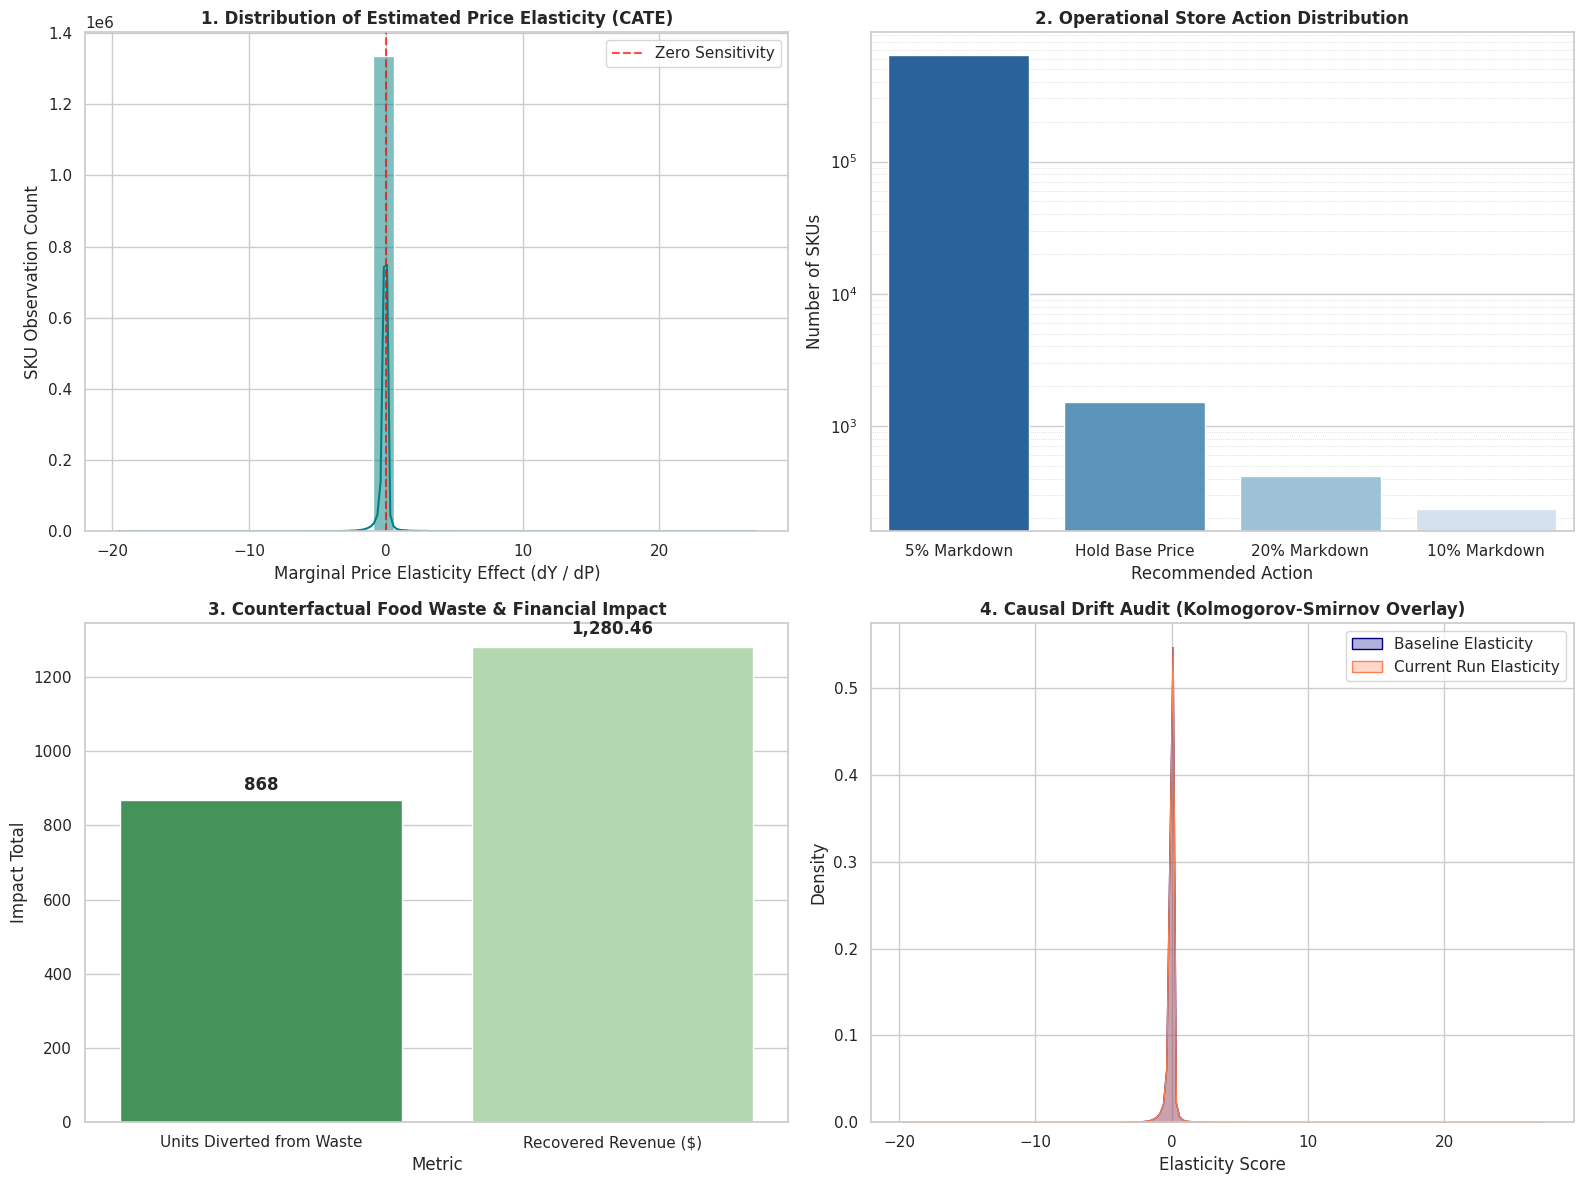

In [24]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd

# Set clean visualization style
sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# ---------------------------------------------------------
# Plot 1: Estimated CATE Price Elasticity Distribution
# ---------------------------------------------------------
sns.histplot(
    df_causal['causal_price_elasticity'], 
    kde=True, 
    color='teal', 
    ax=axes[0, 0],
    bins=30
)
axes[0, 0].set_title("1. Distribution of Estimated Price Elasticity (CATE)", fontsize=12, fontweight='bold')
axes[0, 0].set_xlabel("Marginal Price Elasticity Effect (dY / dP)")
axes[0, 0].set_ylabel("SKU Observation Count")
axes[0, 0].axvline(0, color='red', linestyle='--', alpha=0.7, label='Zero Sensitivity')
axes[0, 0].legend()

# ---------------------------------------------------------
# Plot 2: Recommended Markdown Action Breakdown
# ---------------------------------------------------------
markdown_counts = foods_policy_df['recommended_markdown'].value_counts().reset_index()
markdown_counts.columns = ['Markdown_Type', 'Count']

sns.barplot(
    data=markdown_counts, 
    x='Markdown_Type', 
    y='Count', 
    palette='Blues_r', 
    ax=axes[0, 1]
)
axes[0, 1].set_title("2. Operational Store Action Distribution", fontsize=12, fontweight='bold')
axes[0, 1].set_xlabel("Recommended Action")
axes[0, 1].set_ylabel("Number of SKUs")
axes[0, 1].set_yscale('log')  # Log scale due to large baseline volume
axes[0, 1].grid(True, which="minor", ls=":", linewidth=0.5)

# ---------------------------------------------------------
# Plot 3: Waste Reduction Impact (Saved Units vs. Recovered Revenue)
# ---------------------------------------------------------
impact_data = pd.DataFrame({
    'Metric': ['Units Diverted from Waste', 'Recovered Revenue ($)'],
    'Value': [total_additional_units_saved, total_projected_revenue_recovered]
})

bars = sns.barplot(
    data=impact_data, 
    x='Metric', 
    y='Value', 
    palette='Greens_r', 
    ax=axes[1, 0]
)
axes[1, 0].set_title("3. Counterfactual Food Waste & Financial Impact", fontsize=12, fontweight='bold')
axes[1, 0].set_ylabel("Impact Total")

# Add exact value labels over bars
for bar in bars.patches:
    yval = bar.get_height()
    axes[1, 0].text(
        bar.get_x() + bar.get_width()/2.0, 
        yval + (yval * 0.02), 
        f'{yval:,.2f}' if '$' in str(yval) or yval > 1000 else f'{yval:,.0f}', 
        ha='center', 
        va='bottom', 
        fontweight='bold'
    )

# ---------------------------------------------------------
# Plot 4: Elasticity Drift Stability Check (KS Test Overlay)
# ---------------------------------------------------------
sns.kdeplot(baseline_effects, label='Baseline Elasticity', color='navy', ax=axes[1, 1], fill=True, alpha=0.3)
sns.kdeplot(current_effects, label='Current Run Elasticity', color='coral', ax=axes[1, 1], fill=True, alpha=0.3)
axes[1, 1].set_title("4. Causal Drift Audit (Kolmogorov-Smirnov Overlay)", fontsize=12, fontweight='bold')
axes[1, 1].set_xlabel("Elasticity Score")
axes[1, 1].set_ylabel("Density")
axes[1, 1].legend()

plt.tight_layout()
plt.show()